In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score

print(Pipeline)

<class 'sklearn.pipeline.Pipeline'>


In [5]:
from google.colab import files
uploaded = files.upload()

Saving Titanic.csv to Titanic.csv


In [6]:
df = pd.read_csv("Titanic.csv")

In [7]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley",female,38,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath",female,35,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,NaN,S


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  5 non-null      int64  
 1   Survived     5 non-null      int64  
 2   Pclass       5 non-null      int64  
 3   Name         5 non-null      object 
 4   Sex          5 non-null      object 
 5   Age          5 non-null      int64  
 6   SibSp        5 non-null      int64  
 7   Parch        5 non-null      int64  
 8   Ticket       5 non-null      object 
 9   Fare         5 non-null      float64
 10  Cabin        2 non-null      object 
 11  Embarked     5 non-null      object 
dtypes: float64(1), int64(6), object(5)
memory usage: 612.0+ bytes


In [9]:
df.shape

(5, 12)

In [10]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,5.000000,5.000000,5.000000,5.00000,5.000000,5.0,5.000000
mean,3.000000,0.600000,2.200000,31.20000,0.600000,0.0,29.521660
std,1.581139,0.547723,1.095445,6.83374,0.547723,0.0,30.510029
min,1.000000,0.000000,1.000000,22.00000,0.000000,0.0,7.250000
25%,2.000000,0.000000,1.000000,26.00000,0.000000,0.0,7.925000
50%,3.000000,1.000000,3.000000,35.00000,1.000000,0.0,8.050000
75%,4.000000,1.000000,3.000000,35.00000,1.000000,0.0,53.100000
max,5.000000,1.000000,3.000000,38.00000,1.000000,0.0,71.283300


In [11]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


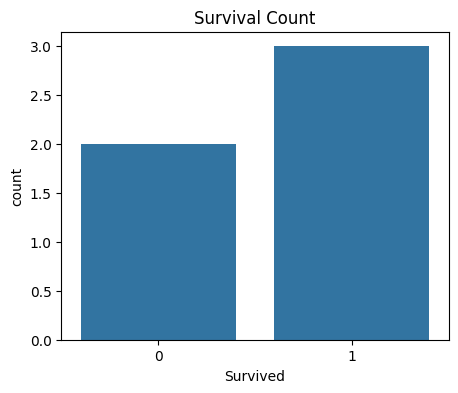

In [12]:
plt.figure(figsize=(5,4))
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

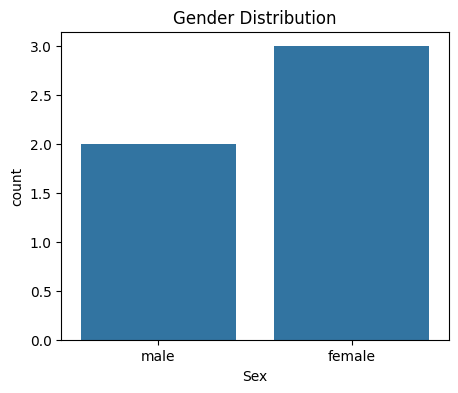

In [13]:
plt.figure(figsize=(5,4))
sns.countplot(x='Sex', data=df)
plt.title("Gender Distribution")
plt.show()

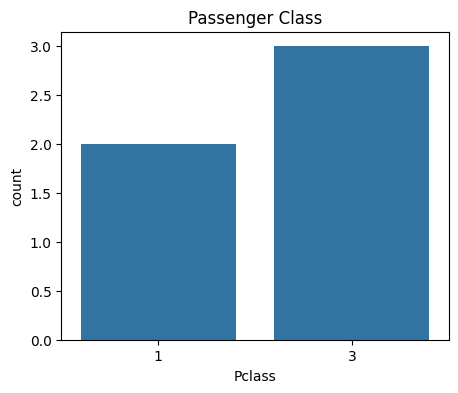

In [14]:
plt.figure(figsize=(5,4))
sns.countplot(x='Pclass', data=df)
plt.title("Passenger Class")
plt.show()

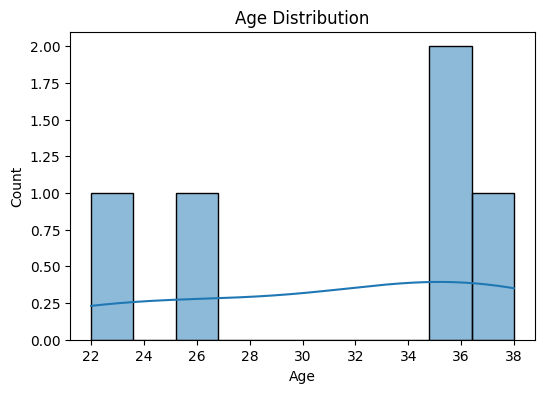

In [15]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=10, kde=True)
plt.title("Age Distribution")
plt.show()

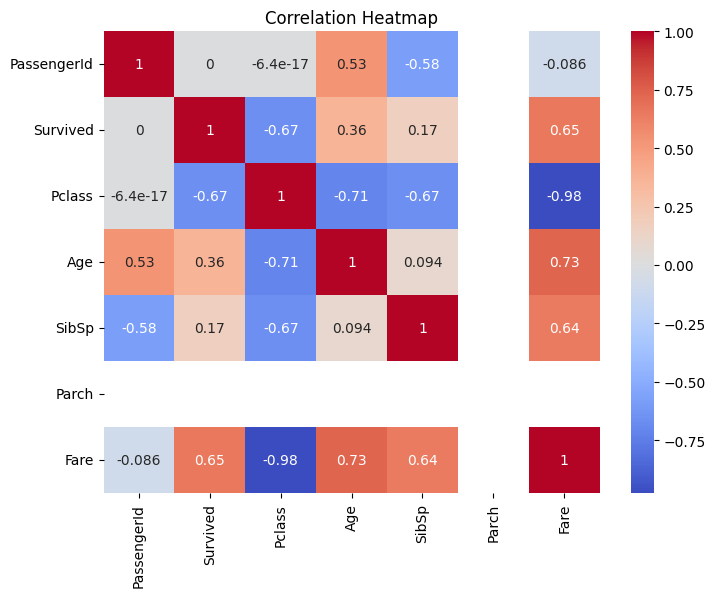

In [16]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [17]:
y = df["Survived"]

X = df.drop("Survived", axis=1)

In [18]:
X = X.drop(columns=["PassengerId","Name","Ticket","Cabin"])

In [19]:
numeric_features = ["Age","Fare"]

categorical_features = ["Sex","Embarked","Pclass"]

In [21]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [22]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [23]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [26]:
print("Training Data Shape:", X_train_processed.shape)
print("Testing Data Shape:", X_test_processed.shape)

Training Data Shape: (4, 7)
Testing Data Shape: (1, 7)


In [27]:
processed_train = pd.DataFrame(
    X_train_processed.toarray()
    if hasattr(X_train_processed, "toarray")
    else X_train_processed
)

processed_train.head()

,0,1,2,3,4,5,6
0,0.968496,-0.561584,0.0,1.0,1.0,0.0,1.0
1,-0.616316,-0.567948,1.0,0.0,1.0,0.0,1.0
2,-1.320676,-0.602311,0.0,1.0,1.0,0.0,1.0
3,0.968496,1.731843,1.0,0.0,1.0,1.0,0.0


In [28]:
processed_train.to_csv("Titanic_Preprocessed.csv", index=False)

In [29]:
processed_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       4 non-null      float64
 1   1       4 non-null      float64
 2   2       4 non-null      float64
 3   3       4 non-null      float64
 4   4       4 non-null      float64
 5   5       4 non-null      float64
 6   6       4 non-null      float64
dtypes: float64(7)
memory usage: 356.0 bytes
